# Classical Clustering: Baseline NLP with HORUS data

This notebook implements the classical NLP clustering baseline for the project. The goal is to group scientific products into thematic clusters using traditional text mining techniques.

The pipeline follows these steps:

1. Load the preprocessed modeling dataset.
2. Select the text column prepared for classical NLP.
3. Build a TF-IDF matrix.
4. Reduce dimensionality with Latent Semantic Analysis (TruncatedSVD) to stabilize clustering.
5. Apply K-Means and Agglomerative Clustering.
6. Evaluate both models with internal clustering metrics.
7. Export labels and metrics for the comparative evaluation notebook.

# 1. Setup and imports

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from gensim.models.ldamulticore import LdaMulticore
from gensim.models import CoherenceModel
from gensim.matutils import Sparse2Corpus
from gensim.corpora import Dictionary

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful.")

All imports successful.


### 1.1. Environment configuration

In [2]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    base_path = Path("/content/drive/Shareddrives/Minería/proyecto_horus/data")
else:
    base_path = Path("../data")

df = pd.read_parquet(base_path / "processed/products_modeling.parquet")

# 2. Load dataset

This dataset already contains preprocessed columns for modeling. For the classical baseline, the most relevant column is expected to be `classical_text_for_modeling`.

In [3]:
print("Dataset shape:", df.shape)
print("Available columns:")
print(df.columns.tolist())

df.head()

Dataset shape: (99064, 16)
Available columns:
['original_title', 'original_description', 'coauthors', 'language', 'type', 'source', 'faculty', 'date', 'journal_conference', 'active_coauthors', '_extreme_coauthors', 'embeddings_text', 'tokens_ngrams', 'classic_text', '_useful_for_modeling', '_useful_for_classical_nlp']


,original_title,original_description,coauthors,language,type,source,faculty,date,journal_conference,active_coauthors,_extreme_coauthors,embeddings_text,tokens_ngrams,classic_text,_useful_for_modeling,_useful_for_classical_nlp
0,None,La producción de conocimiento a través de la i...,Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,01/04/2015,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: La ...,"[producción_conocimiento, investigación, acadé...",producción conocimiento investigación académic...,True,True
1,None,Fruto de un proceso de interacción de más de s...,Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,01/01/2017,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: Fru...,"[fruto, proceso, interacción, mes_diciembre, f...",fruto proceso interacción mes diciembre formal...,True,True
2,None,"Al cierre de la presente edición de INNOVAR, l...",Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,07/04/2017,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: Al ...,"[cierre, presente_edición, innovar, ciudadanía...",cierre presente edición innovar ciudadanía lat...,True,True
3,None,Este número de INNOVAR ve la luz pública en un...,Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,01/10/2016,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: Est...,"[número_innovar, ver_luz, público, contexto, s...",número innovar ver luz público contexto social...,True,True
4,None,"En un editorial previo de INNOVAR, se señalaro...",Gomez Villegas Mauricio,Español,Artículo de revista,RevistasUNAL,Ciencias Económicas,01/01/2015,Revista Innovar Journal,Gomez Villegas Mauricio,False,[Ciencias Económicas] Artículo de revista: En ...,"[editorial, previo, innovar, señalar, reto, ci...",editorial previo innovar señalar reto ciencia ...,True,True


### 2.1. Select rows and text column

Only records marked as useful for classical NLP are used when the `_useful_for_classical_nlp` flag is available. The text column is selected with the following priority:

1. `classical_text_for_modeling`
2. `classic_text`
3. `tokens_ngrams`
4. `embeddings_text`
5. `original_description`

The first option should be used in the current preprocessed dataset.

In [4]:
if "_useful_for_classical_nlp" in df.columns:
    df_classical = df[df["_useful_for_classical_nlp"] == True].copy()
else:
    df_classical = df.copy()

candidate_text_columns = [
    "classical_text_for_modeling",
    "classic_text",
    "tokens_ngrams",
    "embeddings_text",
    "original_description",
]

TEXT_COLUMN = None
for column in candidate_text_columns:
    if column in df_classical.columns:
        TEXT_COLUMN = column
        break

if TEXT_COLUMN is None:
    raise ValueError(f"No valid text column found. Available columns: {df_classical.columns.tolist()}")

def normalize_text(value):
    if isinstance(value, list):
        return " ".join(map(str, value))
    return str(value)

# Preserve the original row index for later merging with other notebooks.
df_classical = df_classical.copy()
df_classical["original_row_index"] = df_classical.index

df_classical["text_for_clustering"] = (
    df_classical[TEXT_COLUMN]
    .fillna("")
    .apply(normalize_text)
    .str.strip()
)

df_classical = df_classical[df_classical["text_for_clustering"].str.len() > 0].reset_index(drop=True)

texts = df_classical["text_for_clustering"]

print(f"Selected text column: {TEXT_COLUMN}")
print("Classical dataframe shape:", df_classical.shape)
texts.head()

Selected text column: classic_text
Classical dataframe shape: (99035, 18)


0    producción conocimiento investigación académic...
1    fruto proceso interacción mes diciembre formal...
2    cierre presente edición innovar ciudadanía lat...
3    número innovar ver luz público contexto social...
4    editorial previo innovar señalar reto ciencia ...
Name: text_for_clustering, dtype: object

# 3. TF-IDF representation

TF-IDF converts each document into a sparse vector that gives more weight to terms that are frequent in a document but not too common across the whole corpus.

`max_features=3000` keeps the representation manageable for clustering while retaining the most informative vocabulary.

In [5]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
    norm="l2"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Vocabulary size:", len(feature_names))

TF-IDF matrix shape: (99035, 3000)
Vocabulary size: 3000


### 3.1. Latent Semantic Analysis for stable clustering

Sparse TF-IDF matrices can make K-Means inertia curves noisy because the space is very high-dimensional. To make the classical clustering baseline more stable and feasible for hierarchical clustering, TF-IDF is reduced with TruncatedSVD, also known as Latent Semantic Analysis (LSA).

This is still a classical NLP approach: it uses TF-IDF term weighting plus matrix factorization, not neural embeddings.

In [6]:
n_samples, n_features = tfidf_matrix.shape
N_COMPONENTS = min(100, n_features - 1, n_samples - 1)

if N_COMPONENTS < 2:
    raise ValueError("Not enough samples or features to perform dimensionality reduction.")

lsa_model = make_pipeline(
    TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE),
    Normalizer(copy=False)
)

lsa_matrix = lsa_model.fit_transform(tfidf_matrix)

explained_variance = lsa_model.named_steps["truncatedsvd"].explained_variance_ratio_.sum()

print("LSA matrix shape:", lsa_matrix.shape)
print(f"Explained variance ratio: {explained_variance:.4f}")

LSA matrix shape: (99035, 100)
Explained variance ratio: 0.1842


# 4. K-Means clustering

K-Means is used as the main classical baseline. Since the number of clusters is not known in advance, the elbow method is used as a practical heuristic.

### 4.1. Elbow method

The elbow method evaluates the K-Means inertia for different values of `k`. A good value is usually near the point where the curve stops decreasing sharply.

The curve is computed on the LSA representation to avoid the noisy behavior often observed when K-Means is applied directly over sparse high-dimensional TF-IDF.

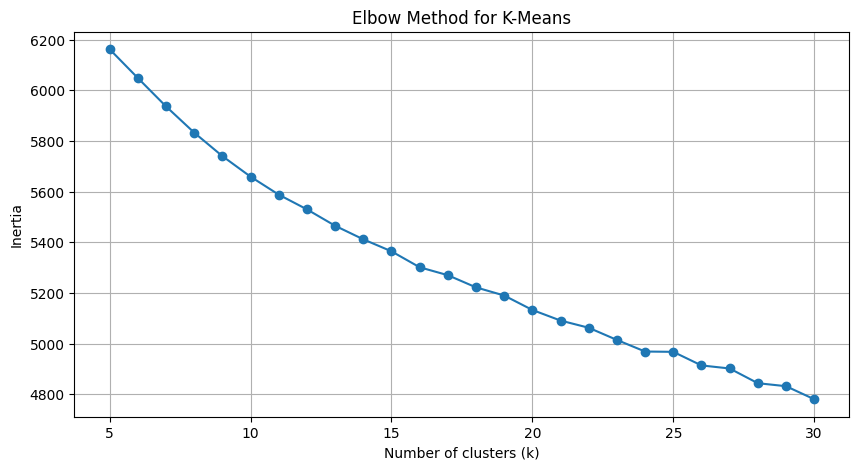

,k,inertia
0,5,6161.939603
1,6,6048.420080
2,7,5936.378410
3,8,5832.831525
4,9,5740.151001
5,10,5658.989794
6,11,5588.029528
7,12,5529.995092
8,13,5465.260636
9,14,5411.741696


In [7]:
K_RANGE = range(5, 31)
MAX_ELBOW_SAMPLE_SIZE = min(8000, lsa_matrix.shape[0])

rng = np.random.default_rng(RANDOM_STATE)
if lsa_matrix.shape[0] > MAX_ELBOW_SAMPLE_SIZE:
    elbow_indices = rng.choice(lsa_matrix.shape[0], size=MAX_ELBOW_SAMPLE_SIZE, replace=False)
    elbow_matrix = lsa_matrix[elbow_indices]
else:
    elbow_matrix = lsa_matrix

inertias = []
for k in K_RANGE:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=50,
        max_iter=500,
        random_state=RANDOM_STATE
    )
    kmeans.fit(elbow_matrix)
    inertias.append(kmeans.inertia_)

elbow_results = pd.DataFrame({
    "k": list(K_RANGE),
    "inertia": inertias
})

plt.figure(figsize=(10, 5))
plt.plot(elbow_results["k"], elbow_results["inertia"], marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

elbow_results

### 4.2. Automatic elbow suggestion

The following helper estimates the elbow by finding the point with the largest distance to the line joining the first and last points of the inertia curve. The final value can still be adjusted manually after inspecting the plot.

In [8]:
def suggest_elbow_k(k_values, inertia_values):
    points = np.column_stack([np.array(k_values, dtype=float), np.array(inertia_values, dtype=float)])
    first_point = points[0]
    last_point = points[-1]
    line_vector = last_point - first_point
    line_length = np.linalg.norm(line_vector)

    if line_length == 0:
        return int(k_values[0])

    distances = np.abs(np.cross(line_vector, first_point - points)) / line_length
    elbow_index = int(np.argmax(distances))
    return int(k_values[elbow_index])

ELBOW_K = suggest_elbow_k(list(K_RANGE), inertias)

print(f"Suggested k according to the elbow heuristic: {ELBOW_K}")

Suggested k according to the elbow heuristic: 13


/tmp/ipykernel_40645/165444724.py:11: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.abs(np.cross(line_vector, first_point - points)) / line_length


### 4.3. Select final K

The selected value of `k` will also be useful for the modern clustering notebook, because the embedding-based K-Means model should use the same number of clusters for a fair comparison.

If the elbow is not clear, keep a medium value that balances interpretability and topic granularity. The automatic suggestion is used by default, but it can be changed manually.

In [9]:
SELECTED_K = ELBOW_K

# Uncomment and edit this line if the team decides to use a fixed shared value.
# SELECTED_K = 12

print(f"Selected number of clusters: {SELECTED_K}")

Selected number of clusters: 13


### 4.4. Fit final K-Means model

In [10]:
kmeans_model = KMeans(
    n_clusters=SELECTED_K,
    init="k-means++",
    n_init=50,
    max_iter=500,
    random_state=RANDOM_STATE
)

kmeans_labels = kmeans_model.fit_predict(lsa_matrix)

df_classical["cluster_classical_kmeans"] = kmeans_labels

print("K-Means labels generated:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means labels generated:
0      4083
1      7407
2      7841
3     14235
4     11474
5      4972
6      3129
7      5663
8      3811
9     25020
10     6278
11     3005
12     2117
Name: count, dtype: int64


### 4.5. Inspect top terms by K-Means cluster

To interpret the clusters, the average TF-IDF weight is computed for each K-Means group. The highest-weighted terms are used as a descriptive approximation of the cluster topic.

In [11]:
def get_top_terms_by_cluster(tfidf_data, labels, feature_names, top_n=10):
    rows = []
    labels = np.array(labels)

    for cluster_id in sorted(np.unique(labels)):
        cluster_mask = labels == cluster_id
        cluster_tfidf = tfidf_data[cluster_mask]
        mean_tfidf = np.asarray(cluster_tfidf.mean(axis=0)).ravel()
        top_indices = mean_tfidf.argsort()[::-1][:top_n]
        top_terms = feature_names[top_indices].tolist()
        rows.append({
            "cluster": int(cluster_id),
            "size": int(cluster_mask.sum()),
            "top_terms": ", ".join(top_terms)
        })

    return pd.DataFrame(rows)

kmeans_top_terms = get_top_terms_by_cluster(
    tfidf_matrix,
    kmeans_labels,
    feature_names,
    top_n=12
)

kmeans_top_terms

,cluster,size,top_terms
0,0,4083,"estudiante, aprendizaje, enseñanza, educación,..."
1,1,7407,"temperature, property, effect, high, obtain, w..."
2,2,7841,"model, system, result, propose, base, problem,..."
3,3,14235,"modelo, sistema, presentar, permitir, proceso,..."
4,4,11474,"social, investigación, proceso, él, política, ..."
5,5,4972,"patient, disease, clinical, result, treatment,..."
6,6,3129,"cell, protein, gene, activity, peptide, expres..."
7,7,5663,"health, development, process, colombia, result..."
8,8,3811,"colombia, nacional, universidad, especie, bogo..."
9,9,25020,"colombiano, sistema, salud, modelo, desarrollo..."


# 5. Agglomerative Clustering

Agglomerative Clustering is the second classical algorithm. This model can be expensive with many rows, so it is run on a reproducible sample when the dataset is large.

The same LSA representation and the same selected number of clusters are used to make it comparable with K-Means.

In [12]:
MAX_AGGLOMERATIVE_SAMPLE_SIZE = min(5000, lsa_matrix.shape[0])

rng = np.random.default_rng(RANDOM_STATE)
if lsa_matrix.shape[0] > MAX_AGGLOMERATIVE_SAMPLE_SIZE:
    agglomerative_indices = rng.choice(
        lsa_matrix.shape[0],
        size=MAX_AGGLOMERATIVE_SAMPLE_SIZE,
        replace=False
    )
else:
    agglomerative_indices = np.arange(lsa_matrix.shape[0])

agglomerative_matrix = lsa_matrix[agglomerative_indices]

agglomerative_model = AgglomerativeClustering(
    n_clusters=SELECTED_K,
    linkage="ward"
)

agglomerative_labels_sample = agglomerative_model.fit_predict(agglomerative_matrix)

# Store labels only for the sampled rows. Non-sampled rows remain missing by design.
df_classical["cluster_classical_agglomerative"] = pd.NA
df_classical.loc[agglomerative_indices, "cluster_classical_agglomerative"] = agglomerative_labels_sample

print("Agglomerative sample size:", len(agglomerative_indices))
print("Agglomerative labels generated on sample:")
print(pd.Series(agglomerative_labels_sample).value_counts().sort_index())

Agglomerative sample size: 5000
Agglomerative labels generated on sample:
0     600
1     856
2     727
3     406
4     505
5     438
6     503
7      79
8     107
9     221
10    197
11    101
12    260
Name: count, dtype: int64


### 5.1. Inspect top terms by Agglomerative cluster

In [13]:
agglomerative_top_terms = get_top_terms_by_cluster(
    tfidf_matrix[agglomerative_indices],
    agglomerative_labels_sample,
    feature_names,
    top_n=12
)

agglomerative_top_terms

,cluster,size,top_terms
0,0,600,"derecho, desarrollo, proceso, colombia, siglo,..."
1,1,856,"colombiano, social, efecto, revista, colombia,..."
2,2,727,"sistema, colombia, especie, diseño, nacional, ..."
3,3,406,"effect, temperature, material, property, obtai..."
4,4,505,"model, system, result, base, propose, differen..."
5,5,438,"modelo, propiedad, ecuación, permitir, sistema..."
6,6,503,"paciente, salud, enfermedad, tratamiento, año,..."
7,7,79,"colombia, uso, páramo, marta, record, justicia..."
8,8,107,"decay, collision, tev, mass, detector, proton,..."
9,9,221,"specie, new, america, colombian, latin, popula..."


# 6. Latent Dirichlet Allocation (LDA)

LDA mathematically requires integer word counts (Bag-of-Words), so we instantiate a `CountVectorizer` instead of using the TF-IDF matrix. We map this sparse matrix to a Gensim corpus to calculate Topic Coherence properly using `CoherenceModel`.

In [14]:
count_vectorizer = CountVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.90
)

count_matrix = count_vectorizer.fit_transform(texts)

# Gensim expects a corpus where columns are documents and rows are features (words), 
# so we pass the count_matrix and set documents_columns=False since rows are documents in count_matrix.
corpus = Sparse2Corpus(count_matrix, documents_columns=False)

# Extract native sklearn vocabulary mapping
vocab_dict = dict((v, k) for k, v in count_vectorizer.vocabulary_.items())

# Convert it to the formal Gensim Dictionary object
gensim_dictionary = Dictionary.from_corpus(corpus, id2word=vocab_dict)

print("Count matrix shape:", count_matrix.shape)
print("Vocabulary size (CountVectorizer):", len(gensim_dictionary))

Count matrix shape: (99035, 3000)
Vocabulary size (CountVectorizer): 3000


### 6.1. Train LDA Model and Calculate Coherence

In [15]:
# We use LdaMulticore for faster training
lda_model = LdaMulticore(
    corpus=corpus,
    id2word=gensim_dictionary,
    num_topics=SELECTED_K,
    random_state=RANDOM_STATE,
    passes=10,
    workers=max(1, os.cpu_count() - 1) if os.cpu_count() else 1
)

# To evaluate the topics qualitatively, we use the Coherence Score (c_v)
# Use the internal analyzer to guarantee identical tokenization
analyzer = count_vectorizer.build_analyzer()
tokenized_texts = [analyzer(text) for text in texts]

coherence_model = CoherenceModel(
    model=lda_model, 
    texts=tokenized_texts, 
    dictionary=gensim_dictionary, 
    coherence='c_v'
)

lda_coherence = coherence_model.get_coherence()
print(f"LDA Coherence Score (c_v) for {SELECTED_K} topics: {lda_coherence:.4f}")

# Extract dominant topic per document for later comparison
# get_document_topics returns a list of (topic_id, probability) for each document
dominant_topics = []
for i, doc in enumerate(corpus):
    topic_probs = lda_model.get_document_topics(doc, minimum_probability=0.0)
    topic_probs = sorted(topic_probs, key=lambda x: x[1], reverse=True)
    dominant_topic = topic_probs[0][0]
    dominant_topics.append(dominant_topic)

df_classical["cluster_classical_lda"] = dominant_topics
print("LDA labels generated on full dataset.")

LDA Coherence Score (c_v) for 13 topics: 0.6851
LDA labels generated on full dataset.


### 6.2. Inspect top terms by LDA cluster

In [16]:
# Extract the top 12 terms for each topic directly from the model
lda_topics = lda_model.show_topics(num_topics=SELECTED_K, num_words=12, formatted=False)
lda_rows = []

for topic_id, word_probs in lda_topics:
    top_terms = [word for word, prob in word_probs]
    lda_rows.append({
        "cluster": topic_id,
        "size": dominant_topics.count(topic_id),
        "top_terms": ", ".join(top_terms)
    })

lda_top_terms = pd.DataFrame(lda_rows)
lda_top_terms

,cluster,size,top_terms
0,0,11821,"especie, efecto, actividad, presentar, compues..."
1,1,16421,"social, investigación, colombia, proceso, públ..."
2,2,9956,"patient, specie, disease, result, high, cell, ..."
3,3,2276,"decay, mass, collision, detector, tev, proton,..."
4,4,1339,"dental, animal, oral, medicina, stress, memory..."
5,5,2009,"él, work, based, used, using, two, abstract, i..."
6,6,8730,"model, system, result, base, datum, propose, t..."
7,7,9906,"paciente, salud, enfermedad, clínico, año, rie..."
8,8,11598,"modelo, sistema, proceso, material, permitir, ..."
9,9,7974,"colombia, desarrollo, investigación, nacional,..."


### 6.3. LDA Visualization with pyLDAvis

In [17]:
import pyLDAvis
import pyLDAvis.gensim_models

pyLDAvis.enable_notebook()

# Prepare the visualization using the gensim model
vis = pyLDAvis.gensim_models.prepare(
    topic_model=lda_model, 
    corpus=corpus, 
    dictionary=gensim_dictionary
)

# Display the visualization natively
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.301669  0.051210       1        1  13.092919
2      0.288014  0.003280       2        1  12.555890
8     -0.314417  0.001306       3        1  11.560241
6      0.314926 -0.001374       4        1   9.564701
0     -0.298983  0.005987       5        1   9.563103
7     -0.293226 -0.007557       6        1   8.738594
10     0.268394  0.081966       7        1   8.559508
11     0.298309 -0.001592       8        1   8.175682
9     -0.304225  0.053321       9        1   7.636206
5     -0.058855  0.102462      10        1   4.022371
12     0.154970  0.140100      11        1   2.897735
3      0.254259 -0.035453      12        1   2.705644
4     -0.007498 -0.393656      13        1   0.927407, topic_info=             Term          Freq         Total Category  logprob  loglift
112      colombia  35266.000000  35266.000000  Default  30.0000  30.0000
1900     paciente  11232.000000  11232.000000  Default  29.0000  29.0000
915         model  17533.000000  17533.000000  Default  28.0000  28.0000
1712      patient  10934.000000  10934.000000  Default  27.0000  27.0000
30         social  15675.000000  15675.000000  Default  26.0000  26.0000
...           ...           ...           ...      ...      ...      ...
959        imagen    540.572875   2768.029454  Topic13  -4.3930   3.0473
7     universidad    761.002308   7989.801348  Topic13  -4.0510   2.3292
344      nacional    439.802181  11172.723943  Topic13  -4.5993   1.4456
479   aprendizaje    408.051082   3433.463326  Topic13  -4.6742   2.5506
201       control    389.191702  12830.574433  Topic13  -4.7215   1.1850

[823 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
1800      1  0.001789  abstract
1800      2  0.080969  abstract
1800      4  0.067548  abstract
1800      5  0.000447  abstract
1800      7  0.259904  abstract
...     ...       ...       ...
42       10  0.135351        él
42       11  0.000424        él
42       13  0.002037        él
2926      3  0.979570    óptico
2926      5  0.019641    óptico

[3605 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 9, 7, 1, 8, 11, 12, 10, 6, 13, 4, 5])

# 7. Internal evaluation

Internal metrics evaluate the compactness and separation of the clusters without using external labels.

Metrics included:

- **Silhouette Score:** higher is better.
- **Calinski-Harabasz Score:** higher is better.
- **Davies-Bouldin Score:** lower is better.

For efficiency and comparability, K-Means is evaluated on the same sample used for the Agglomerative model when possible.
Note: LDA is excluded from geometric evaluation (Silhouette, Calinski-Harabasz, Davies-Bouldin) because it is a probabilistic generative model, not a distance-based clustering algorithm. Its performance is evaluated through Coherence Score and Top Terms instead.

In [18]:
def safe_internal_metrics(matrix, labels, model_name):
    labels = np.array(labels)
    unique_labels = np.unique(labels)

    if len(unique_labels) < 2:
        return {
            "model": model_name,
            "n_samples": matrix.shape[0],
            "n_clusters": len(unique_labels),
            "silhouette_score": np.nan,
            "calinski_harabasz_score": np.nan,
            "davies_bouldin_score": np.nan,
        }

    return {
        "model": model_name,
        "n_samples": matrix.shape[0],
        "n_clusters": len(unique_labels),
        "silhouette_score": silhouette_score(matrix, labels, metric="euclidean"),
        "calinski_harabasz_score": calinski_harabasz_score(matrix, labels),
        "davies_bouldin_score": davies_bouldin_score(matrix, labels),
    }

kmeans_labels_on_sample = kmeans_labels[agglomerative_indices]

metrics_results = pd.DataFrame([
    safe_internal_metrics(agglomerative_matrix, kmeans_labels_on_sample, "K-Means + TF-IDF/LSA"),
    safe_internal_metrics(agglomerative_matrix, agglomerative_labels_sample, "Agglomerative + TF-IDF/LSA"),
])

metrics_results

,model,n_samples,n_clusters,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,K-Means + TF-IDF/LSA,5000,13,0.077892,129.671277,2.901566
1,Agglomerative + TF-IDF/LSA,5000,13,0.051081,106.056123,3.458109


# 8. Export results

The outputs are saved in the shared Drive folder under `proyecto_horus/outputs/`. These files can be used later by the comparative evaluation notebook.



In [19]:
PROJECT_DIR = base_path.parent
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

labels_output_path = OUTPUT_DIR / "04_classical_clustering_labels.parquet"
metrics_output_path = OUTPUT_DIR / "04_classical_clustering_metrics.csv"
top_terms_kmeans_path = OUTPUT_DIR / "04_classical_kmeans_top_terms.csv"
top_terms_agglomerative_path = OUTPUT_DIR / "04_classical_agglomerative_top_terms.csv"
top_terms_lda_path = OUTPUT_DIR / "04_classical_lda_top_terms.csv"
elbow_output_path = OUTPUT_DIR / "04_classical_elbow_results.csv"
lda_vis_output_path = OUTPUT_DIR / "04_classical_lda_vis.html"

export_columns = [
    "original_row_index",
    "cluster_classical_kmeans",
    "cluster_classical_agglomerative",
    "cluster_classical_lda",
]

for optional_column in ["original_title", "faculty", "type", "source", "date"]:
    if optional_column in df_classical.columns:
        export_columns.append(optional_column)

labels_output = df_classical[export_columns].copy()

labels_output.to_parquet(labels_output_path, index=False)
metrics_results.to_csv(metrics_output_path, index=False)
kmeans_top_terms.to_csv(top_terms_kmeans_path, index=False)
agglomerative_top_terms.to_csv(top_terms_agglomerative_path, index=False)
lda_top_terms.to_csv(top_terms_lda_path, index=False)
elbow_results.to_csv(elbow_output_path, index=False)

pyLDAvis.save_html(vis, str(lda_vis_output_path))

print("Saved files in shared Drive:")
print(labels_output_path)
print(metrics_output_path)
print(top_terms_kmeans_path)
print(top_terms_agglomerative_path)
print(top_terms_lda_path)
print(elbow_output_path)
print(lda_vis_output_path)

Saved files in shared Drive:
../outputs/04_classical_clustering_labels.parquet
../outputs/04_classical_clustering_metrics.csv
../outputs/04_classical_kmeans_top_terms.csv
../outputs/04_classical_agglomerative_top_terms.csv
../outputs/04_classical_lda_top_terms.csv
../outputs/04_classical_elbow_results.csv
../outputs/04_classical_lda_vis.html


# 9. Brief interpretation

The classical baseline incorporates three models: K-Means, Agglomerative Clustering, and Latent Dirichlet Allocation (LDA). K-Means and Agglomerative Clustering were built using TF-IDF and Latent Semantic Analysis (LSA). LDA, being a probabilistic generative model, was built directly over a Bag-of-Words (CountVectorizer) representation to properly preserve the topic-word distributions, acting as the true historical baseline of the HORUS platform.

The elbow method on the LSA space was used to choose the number of clusters, and this identical `k` was applied across K-Means, Agglomerative, and LDA. This balances interpretability and granularity, and ensures consistency when comparing with the modern embedding-based clustering pipeline later on.

The top terms per cluster, alongside the LDA Coherence Score and interactive pyLDAvis exploration, provide a human-readable interpretation of the discovered topics. K-Means and Agglomerative models were additionally evaluated via internal geometric metrics. All generated labels and results are exported for the final comparative evaluation.